In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any

from xgboost import XGBClassifier

import xgboost as xgb
import lightgbm as lgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve, auc

In [2]:
import matplotlib

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [4]:
def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [5]:
# Download the dataset
raw_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/train.csv', index_col=0)

# Target column
target_col = 'Exited'

In [6]:
train_df, val_df = split_train_val(raw_df, target_col=target_col)

In [7]:
input_cols = [col for col in train_df.columns[2:-1]]

In [8]:
train_inputs, train_targets = separate_inputs_targets(train_df, input_cols=input_cols, target_col=target_col)
val_inputs, val_targets = separate_inputs_targets(val_df, input_cols=input_cols, target_col=target_col)

1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [9]:
cat_features = train_inputs.select_dtypes(include='object').columns
train_inputs[cat_features] = train_inputs[cat_features].astype('category')
val_inputs[cat_features] = val_inputs[cat_features].astype('category')

2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [10]:
xgb_clf = XGBClassifier(
    max_depth=3,
    n_estimators=10,
    enable_categorical=True,
    #use_label_encoder=False,
    missing=np.nan,
    device='cuda',
    random_state=42
)

xgb_clf.fit(train_inputs, train_targets)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:15:23] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:15:23] WARNING: /__w/xgboost/xgboost/src/context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=10,
              n_jobs=None, num_parallel_tree=None, ...)

In [11]:
def compute_auroc_and_build_roc(model, inputs, targets, name=''):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

AUROC for Training: 0.93


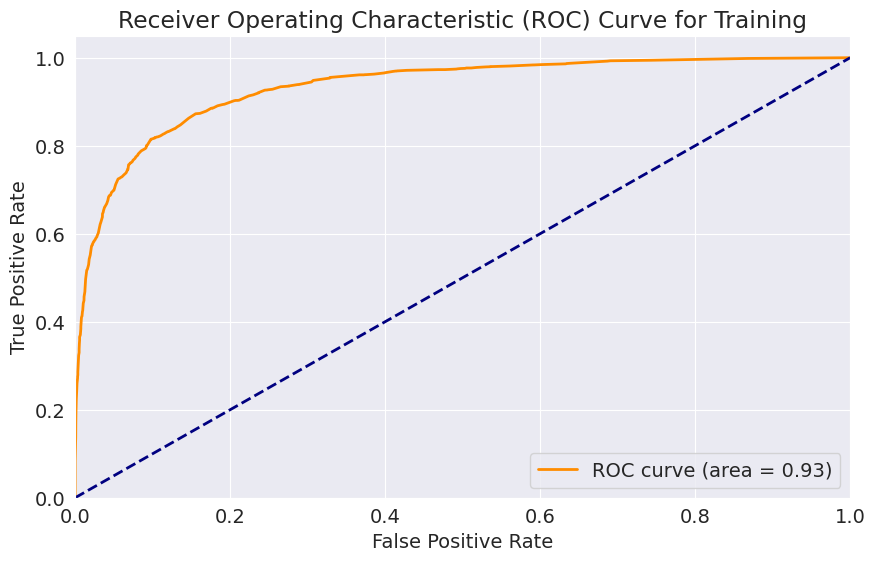

AUROC for Validation: 0.93


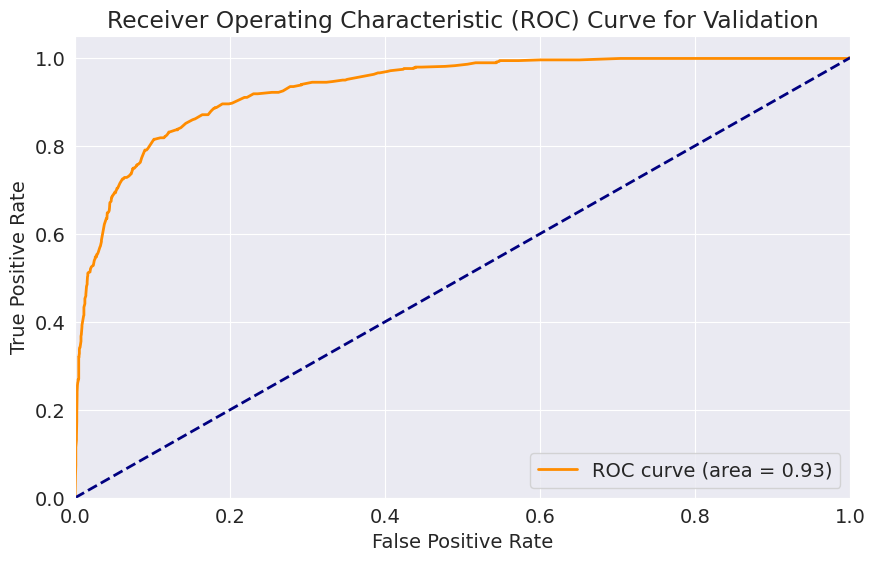

In [12]:
compute_auroc_and_build_roc(xgb_clf, train_inputs, train_targets, 'Training')
compute_auroc_and_build_roc(xgb_clf, val_inputs, val_targets, 'Validation')

Отримали хорошу точність моделі:
- на тренувальних даних AUROC = 0.93
- на валідаційних даних AUROC = 0.93

Отже, у моделі не спострегіється недо- і перенавчання

Порівняно з результатами моделі DecisionTree, модель XGBoost показує трохи кращі результати на валідаційних даних: 0.93 проти 0.92 для дерева

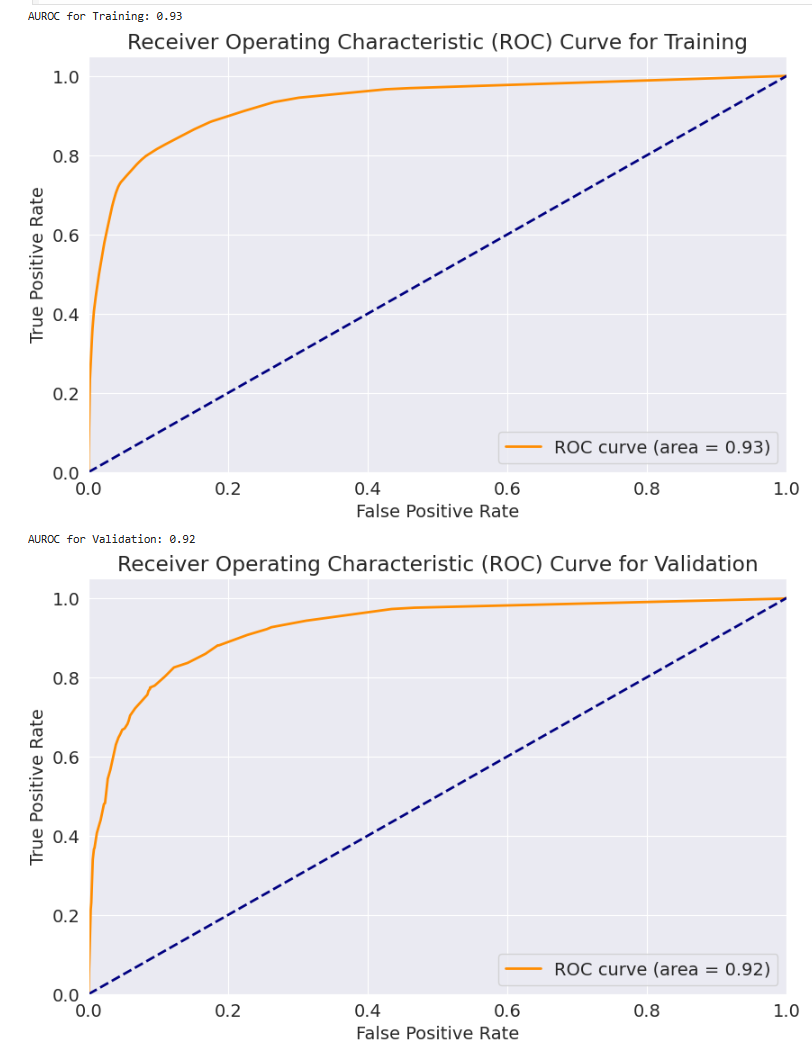

3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [14]:
!pip install hyperopt

In [15]:
?XGBClassifier

  0%|          | 0/20 [00:00<?, ?trial/s, best loss=?]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [23:15:36] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [23:15:36] WARNING: /__w/xgboost/xgboost/src/context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()



  5%|▌         | 1/20 [00:00<00:08,  2.16trial/s, best loss: -0.9286401673640168]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [23:15:36] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [23:15:36] WARNING: /__w/xgboost/xgboost/src/context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()



 10%|█         | 2/20 [00:01<00:10,  1.68trial/s, best loss: -0.932464160779203] 

...

 95%|█████████▌| 19/20 [00:05<00:00,  5.57trial/s, best loss: -0.9376641059057548]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [23:15:41] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [23:15:41] WARNING: /__w/xgboost/xgboost/src/context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [23:15:42] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [23:15:42] WARNING: /__w/xgboost/xgboost/src/context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_roun

100%|██████████| 20/20 [00:07<00:00,  2.52trial/s, best loss: -0.9376641059057548]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.7127992865398958), 'gamma': np.float64(0.07998132257780388), 'learning_rate': np.float64(0.1752471225111574), 'max_delta_step': 4, 'max_depth': 3, 'min_child_weight': 6, 'n_estimators': 225, 'reg_alpha': np.float64(0.26565557354317404), 'reg_lambda': np.float64(0.732879627110589), 'subsample': np.float64(0.5910081165482702)}


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [23:15:44] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [23:15:44] WARNING: /__w/xgboost/xgboost/src/context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


Точність на Train вибірці:

AUROC for Training: 0.94


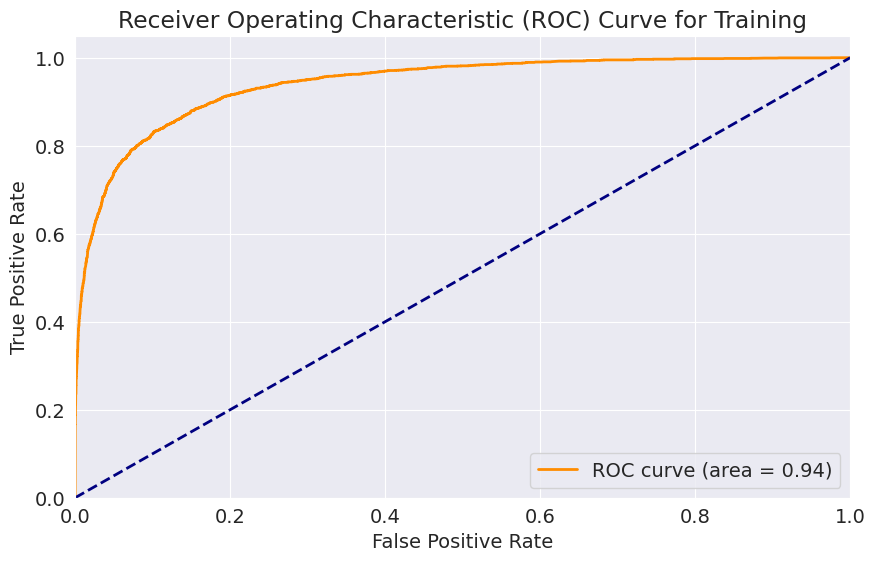

Точність на Validation вибірці:

AUROC for Validation: 0.94


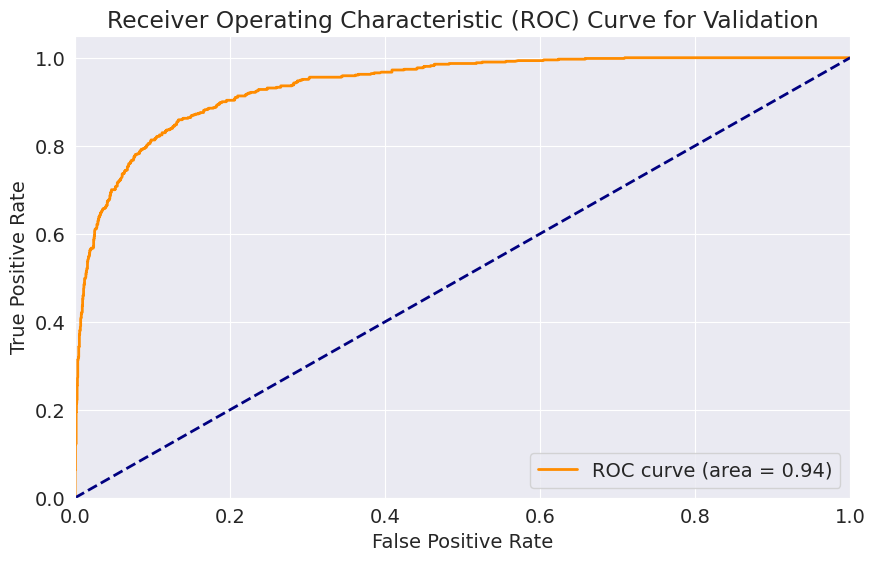

In [13]:
def objective(params):
    clf = xgb.XGBClassifier(
        n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=params['min_child_weight'],
        max_delta_step=params['max_delta_step'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        gamma=params['gamma'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        #max_leaves=int(params['max_leaves']),
        enable_categorical=True,
        missing=np.nan,
        device='cuda',
        eval_metric='auc',
        early_stopping_rounds=10,
        random_state=42
    )

    clf.fit(
        train_inputs,
        train_targets,
        eval_set=[(val_inputs, val_targets)],
        verbose=False)

    pred = clf.predict_proba(val_inputs)[:, 1]
    auroc = roc_auc_score(val_targets, pred)

    return {'loss': -auroc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'max_delta_step': hp.quniform('max_delta_step', 0, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])
best['max_delta_step'] = int(best['max_delta_step'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf_xgb = xgb.XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    max_delta_step=best['max_delta_step'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    missing=np.nan,
    device='cuda',
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=10
)

final_clf_xgb.fit(
    train_inputs,
    train_targets,
    eval_set=[(val_inputs, val_targets)],
    verbose=False)

print("Точність на Train вибірці:\n")
compute_auroc_and_build_roc(final_clf_xgb, train_inputs, train_targets, 'Training')
print("Точність на Validation вибірці:\n")
compute_auroc_and_build_roc(final_clf_xgb, val_inputs, val_targets, 'Validation')

In [46]:
best_xgb = best
display(best_xgb)

{'colsample_bytree': np.float64(0.812199349783745),
 'gamma': np.float64(0.2795763272777189),
 'learning_rate': np.float64(0.22266129405424773),
 'max_delta_step': 2,
 'max_depth': 4,
 'min_child_weight': 2,
 'n_estimators': 475,
 'reg_alpha': np.float64(0.997880346713599),
 'reg_lambda': np.float64(0.1860462216577451),
 'subsample': np.float64(0.8604395406977444)}

Бачимо, що модель стала якіснішою. AUROC зріс до 0.94 для тренувальної та валідаційної вибірок

4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [ ]:
# %%bash
# sudo apt-get update
# sudo apt-get install -y build-essential cmake git wget unzip
# sudo apt-get install -y libboost-dev libboost-system-dev libboost-filesystem-dev
# sudo apt-get install -y libboost-iostreams-dev libboost-program-options-dev libboost-regex-dev
# sudo apt-get install -y libboost-thread-dev libboost-chrono-dev libboost-date-time-dev
# sudo apt-get install -y libboost-atomic-dev libboost-serialization-dev
# sudo apt-get install -y python3-pip

In [ ]:
# %%bash
# sudo apt-get install -y ocl-icd-libopencl1 clinfo
# sudo apt-get install -y nvidia-opencl-dev opencl-headers

In [ ]:
# !rm -rf /content/LightGBM
# !git clone --recursive --branch v4.6.0 https://github.com/microsoft/LightGBM.git

In [ ]:
# %cd /content/LightGBM
# !mkdir build
# %cd build
# !cmake -DUSE_CUDA=ON ..

In [ ]:
# !make -j2

In [ ]:
# %%bash
# cd /content/LightGBM
# sh build-python.sh install

In [18]:
# import lightgbm as lgb

# print(lgb.__version__)
# print(lgb.__file__)

4.6.0
/usr/local/lib/python3.12/dist-packages/lightgbm/__init__.py


In [14]:
cat_feature_indexes = [train_inputs.columns.get_loc(col) for col in cat_features]

[LightGBM] [Warning] categorical_feature is set with categorical_column=1,2, will be overridden by cat_feature=1,2. Current value: categorical_feature=1,2
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001154 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

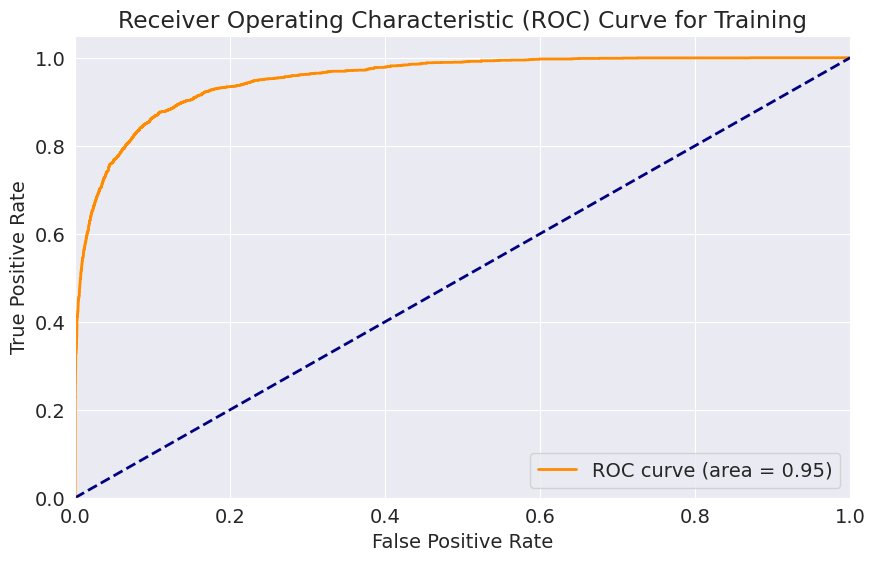

AUROC for Validation: 0.94


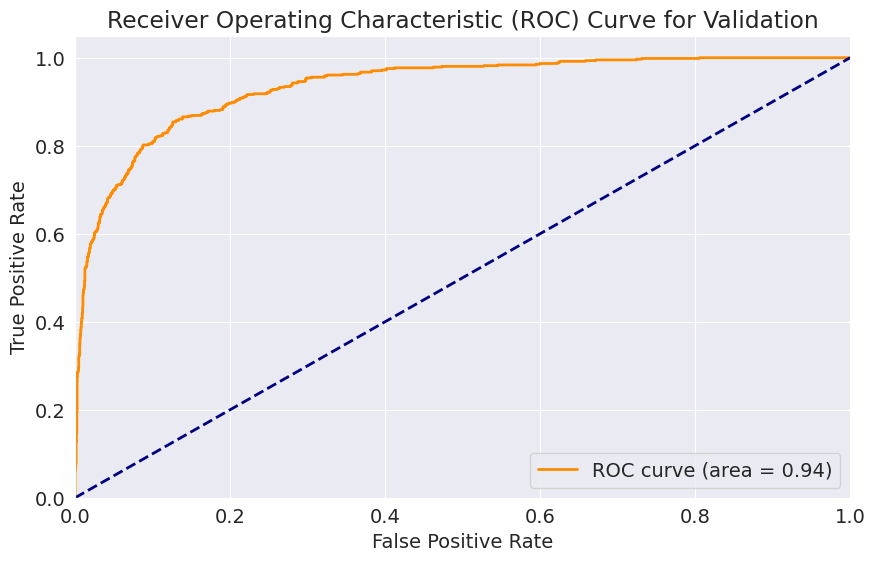

In [15]:
lgb_clf = lgb.LGBMClassifier(
    max_depth=5,
    n_estimators=60,
    learning_rate=0.1,
    cat_feature=cat_feature_indexes,
    #missing=np.nan,
    #device='cuda',
    random_state=42,
    metric='auc'
)

lgb_clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)])

compute_auroc_and_build_roc(lgb_clf, train_inputs, train_targets, 'Training')
compute_auroc_and_build_roc(lgb_clf, val_inputs, val_targets, 'Validation')

Бачимо, що модель трохи перенавчилася, оскільки AUROC на валідаційних даних нижча, ніж на тренувальних

5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] categorical_feature is set with cat_feature=1,2, categorical_column=1,2 will be ignored. Current value: categorical_feature=1,2
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001553 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 12000

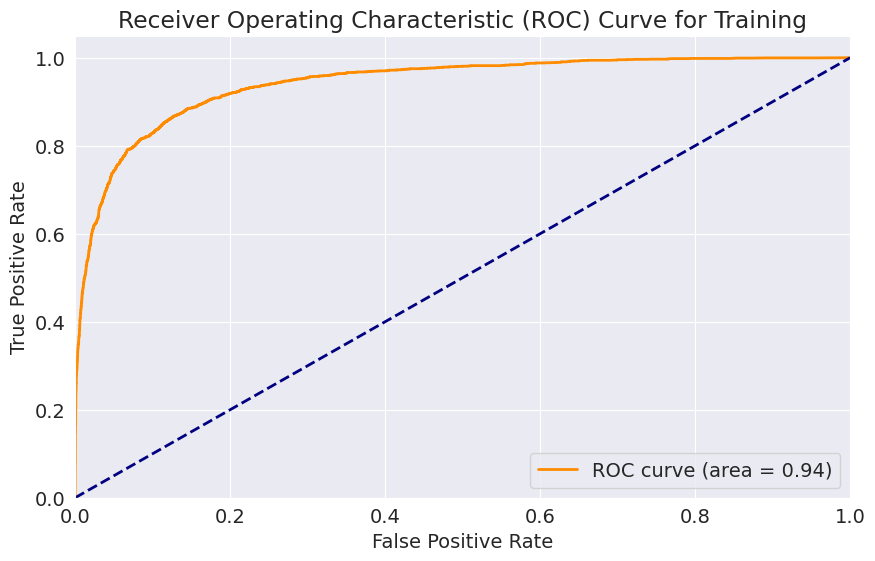

Точність на Validation вибірці:

[LightGBM] [Warning] min_data_in_leaf is set=28, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=28
[LightGBM] [Warning] bagging_freq is set=10, subsample_freq=0 will be ignored. Current value: bagging_freq=10
AUROC for Validation: 0.94


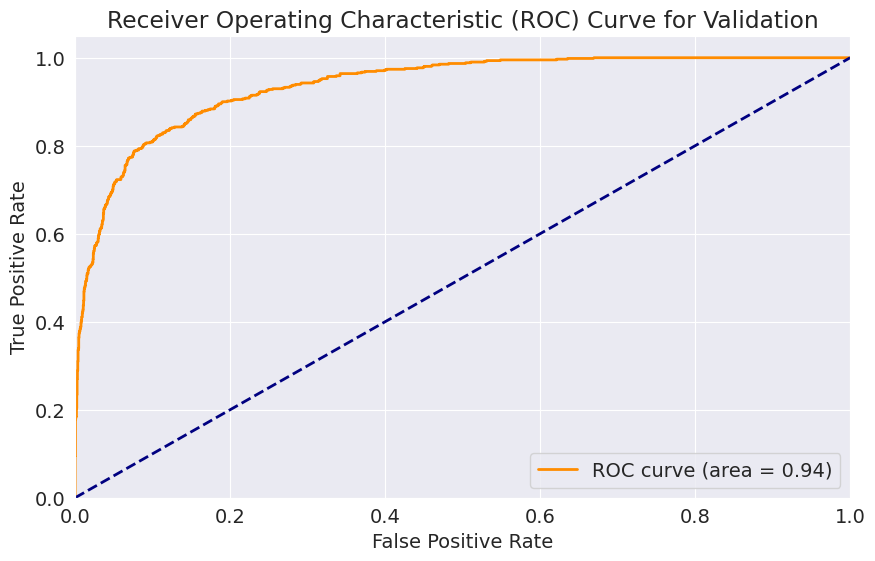

In [16]:
def objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        num_leaves=int(params['num_leaves']),
        min_child_weight=params['min_child_weight'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        min_split_gain=params['min_split_gain'],
        min_data_in_leaf=int(params['min_data_in_leaf']),
        feature_fraction_bynode=params['feature_fraction_bynode'],
        bagging_freq=int(params['bagging_freq']),
        cat_feature=cat_feature_indexes,
        #device='cuda',
        random_state=42,
        early_stopping_round=10,
        metric='auc'
    )

    clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)], categorical_feature=cat_feature_indexes)

    pred = clf.predict_proba(val_inputs)[:, 1]
    auroc = roc_auc_score(val_targets, pred)

    return {'loss': -auroc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 20),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.1),
    'min_data_in_leaf': hp.quniform('min_data_in_leaf', 5, 30, 1),
    'feature_fraction_bynode': hp.uniform('feature_fraction_bynode', 0.6, 1.0),
    'bagging_freq': hp.quniform('bagging_freq', 1, 10, 1)
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['num_leaves'] = int(best['num_leaves'])
best['min_child_weight'] = int(best['min_child_weight'])
best['min_data_in_leaf'] = int(best['min_data_in_leaf'])
best['bagging_freq'] = int(best['bagging_freq'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf_lgb = lgb.LGBMClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    num_leaves=best['num_leaves'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    min_split_gain=best['min_split_gain'],
    min_data_in_leaf=best['min_data_in_leaf'],
    feature_fraction_bynode=best['feature_fraction_bynode'],
    bagging_freq=best['bagging_freq'],
    cat_feature=cat_feature_indexes,
    #device='cuda',
    random_state=42,
    early_stopping_round=10,
    metric='auc'
)

final_clf_lgb.fit(
    train_inputs,
    train_targets,
    eval_set=[(val_inputs, val_targets)],
    categorical_feature=cat_feature_indexes)

print("Точність на Train вибірці:\n")
compute_auroc_and_build_roc(final_clf_lgb, train_inputs, train_targets, 'Training')
print("Точність на Validation вибірці:\n")
compute_auroc_and_build_roc(final_clf_lgb, val_inputs, val_targets, 'Validation')


In [17]:
best_lgb = best
display(best_lgb)

{'bagging_freq': 10,
 'colsample_bytree': np.float64(0.6997234993267403),
 'feature_fraction_bynode': np.float64(0.7071465697536621),
 'learning_rate': np.float64(0.05419408024484813),
 'max_depth': 9,
 'min_child_weight': 9,
 'min_data_in_leaf': 28,
 'min_split_gain': np.float64(0.08966184677498185),
 'n_estimators': 260,
 'num_leaves': 46,
 'reg_alpha': np.float64(0.6578235012911827),
 'reg_lambda': np.float64(0.8073427718644806),
 'subsample': np.float64(0.6741952868026586)}

Отриманий результат має такі ж показники якості, як і для AUROC моделі XGBoost

Спробую оцінити, чи збільшення max_evals до 20 покращить результат

[LightGBM] [Warning] min_data_in_leaf is set=9, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=9
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] categorical_feature is set with cat_feature=1,2, categorical_column=1,2 will be ignored. Current value: categorical_feature=1,2
[LightGBM] [Warning] min_data_in_leaf is set=9, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=9
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002423 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 12000, nu

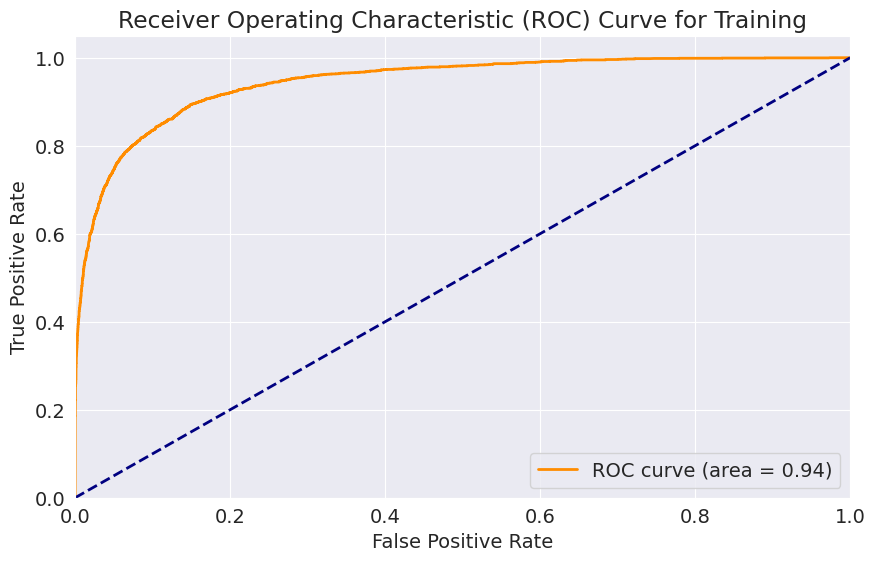

Точність на Validation вибірці:

[LightGBM] [Warning] min_data_in_leaf is set=22, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=22
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
AUROC for Validation: 0.94


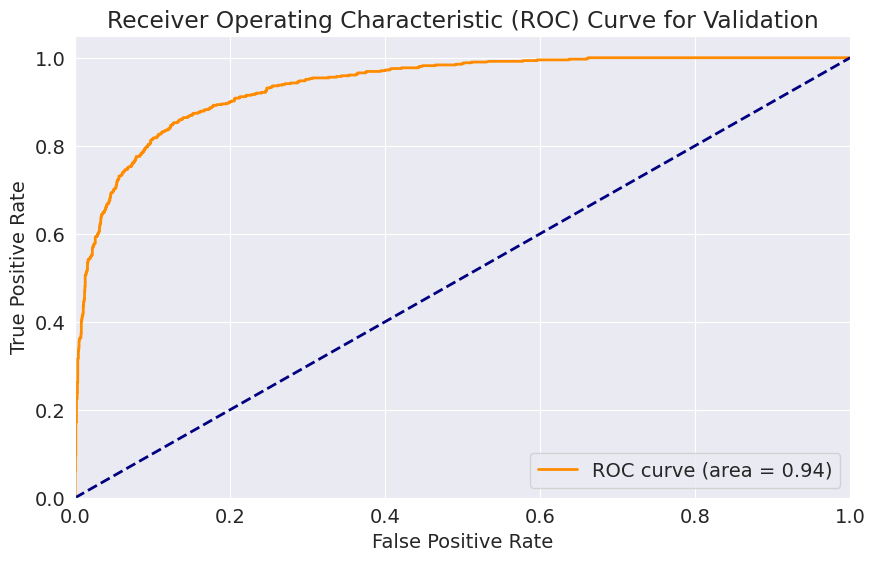

In [18]:
def objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params['n_estimators']),  # Кількість дерев у ансамблі (кількість ітерацій бустингу)
        learning_rate=params['learning_rate'],  # Коефіцієнт, на який зменшується внесок кожного доданого дерева
        max_depth=int(params['max_depth']),  # Максимальна глибина кожного дерева
        num_leaves=int(params['num_leaves']),  # Максимальна кількість листків, що дозволяємо кожному дереву мати.
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        min_split_gain=params['min_split_gain'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        min_data_in_leaf=int(params['min_data_in_leaf']),
        feature_fraction_bynode=params['feature_fraction_bynode'],
        bagging_freq=int(params['bagging_freq']),
        cat_feature=cat_feature_indexes,  # Індекси категорійних ознак
        #device='cuda',
        random_state=42,
        early_stopping_round=10,
        metric='auc'
    )

    clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)], categorical_feature=cat_feature_indexes)

    pred = clf.predict_proba(val_inputs)[:, 1]
    auroc = roc_auc_score(val_targets, pred)

    return {'loss': -auroc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 20),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'max_depth': hp.quniform('max_depth', 3, 7, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.1),  # додано мінімальне зменшення втрат для поділу
    'min_data_in_leaf': hp.quniform('min_data_in_leaf', 5, 30, 1),
    'feature_fraction_bynode': hp.uniform('feature_fraction_bynode', 0.6, 1.0),
    'bagging_freq': hp.quniform('bagging_freq', 1, 10, 1)
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['num_leaves'] = int(best['num_leaves'])
best['min_child_weight'] = int(best['min_child_weight'])
best['min_data_in_leaf'] = int(best['min_data_in_leaf'])
best['bagging_freq'] = int(best['bagging_freq'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf_lgb_20 = lgb.LGBMClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    num_leaves=best['num_leaves'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    min_split_gain=best['min_split_gain'],
    min_data_in_leaf=best['min_data_in_leaf'],
    feature_fraction_bynode=best['feature_fraction_bynode'],
    bagging_freq=best['bagging_freq'],
    cat_feature=cat_feature_indexes,
    #device='cuda',
    random_state=42,
    early_stopping_round=10,
    metric='auc'
)

final_clf_lgb_20.fit(
    train_inputs,
    train_targets,
    eval_set=[(val_inputs, val_targets)],
    categorical_feature=cat_feature_indexes)

print("Точність на Train вибірці:\n")
compute_auroc_and_build_roc(final_clf_lgb_20, train_inputs, train_targets, 'Training')
print("Точність на Validation вибірці:\n")
compute_auroc_and_build_roc(final_clf_lgb_20, val_inputs, val_targets, 'Validation')

In [19]:
best_lgb_20 = best
display(best_lgb_20)

{'bagging_freq': 3,
 'colsample_bytree': np.float64(0.6641686746715136),
 'feature_fraction_bynode': np.float64(0.9620119293938079),
 'learning_rate': np.float64(0.07458625618946506),
 'max_depth': 5,
 'min_child_weight': 3,
 'min_data_in_leaf': 22,
 'min_split_gain': np.float64(0.02140121691141659),
 'n_estimators': 300,
 'num_leaves': 85,
 'reg_alpha': np.float64(0.568804219490718),
 'reg_lambda': np.float64(0.23183166686764167),
 'subsample': np.float64(0.7838762362893582)}

Глобального покращення не спостерігається  
Для поточної кількості ітерацій 10 спробую оптимізувати меншу кількість гіперпараметрів. Можливо, це покращить якість пошуку для основних параметрів та покращить якість моделі

[LightGBM] [Warning] categorical_feature is set with cat_feature=1,2, categorical_column=1,2 will be ignored. Current value: categorical_feature=1,2
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002967 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

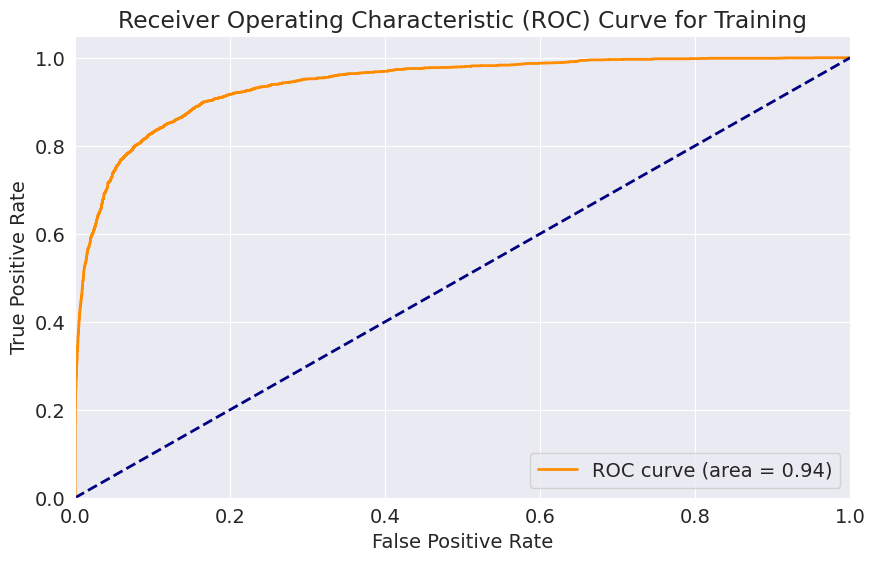

Точність на Validation вибірці:

AUROC for Validation: 0.94


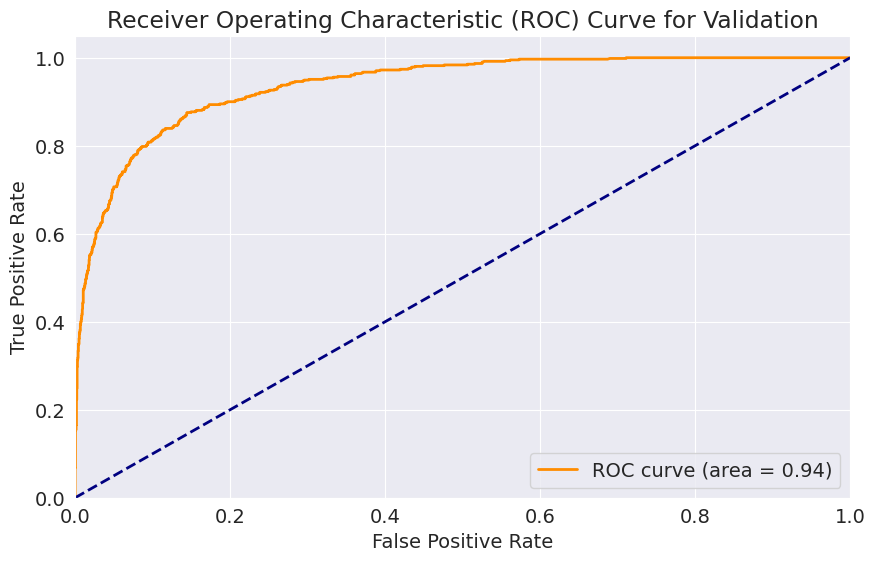

In [32]:
def objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params['n_estimators']),  # Кількість дерев у ансамблі (кількість ітерацій бустингу)
        learning_rate=params['learning_rate'],  # Коефіцієнт, на який зменшується внесок кожного доданого дерева
        max_depth=int(params['max_depth']),  # Максимальна глибина кожного дерева
        num_leaves=int(params['num_leaves']),  # Максимальна кількість листків, що дозволяємо кожному дереву мати.
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        min_split_gain=params['min_split_gain'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        cat_feature=cat_feature_indexes,  # Індекси категорійних ознак
        #device='cuda',
        random_state=42,
        early_stopping_round=10,
        metric='auc'
    )

    clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)], categorical_feature=cat_feature_indexes)

    pred = clf.predict_proba(val_inputs)[:, 1]
    auroc = roc_auc_score(val_targets, pred)

    return {'loss': -auroc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 20),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'max_depth': hp.quniform('max_depth', 3, 6, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 64, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1.5),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.1)  # додано мінімальне зменшення втрат для поділу
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['num_leaves'] = int(best['num_leaves'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf_lgb_min = lgb.LGBMClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    num_leaves=best['num_leaves'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    min_split_gain=best['min_split_gain'],
    cat_feature=cat_feature_indexes,
    #device='cuda',
    random_state=42,
    early_stopping_round=10,
    metric='auc'
)

final_clf_lgb_min.fit(
    train_inputs,
    train_targets,
    eval_set=[(val_inputs, val_targets)],
    categorical_feature=cat_feature_indexes)

print("Точність на Train вибірці:\n")
compute_auroc_and_build_roc(final_clf_lgb_min, train_inputs, train_targets, 'Training')
print("Точність на Validation вибірці:\n")
compute_auroc_and_build_roc(final_clf_lgb_min, val_inputs, val_targets, 'Validation')

In [31]:
best_lgb_min = best
print(best_lgb_min)

{'colsample_bytree': np.float64(0.5306248541402272), 'learning_rate': np.float64(0.08902515792322362), 'max_depth': 6, 'min_child_weight': 2, 'min_split_gain': np.float64(0.01355152123811193), 'n_estimators': 240, 'num_leaves': 129, 'reg_alpha': np.float64(0.5202569510052617), 'reg_lambda': np.float64(0.21523550555651028), 'subsample': np.float64(0.7279372254616792)}


Кращий результат. Спробую покращити звузивши поле значень гіперпараметрів

[LightGBM] [Warning] categorical_feature is set with cat_feature=1,2, categorical_column=1,2 will be ignored. Current value: categorical_feature=1,2
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001814 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

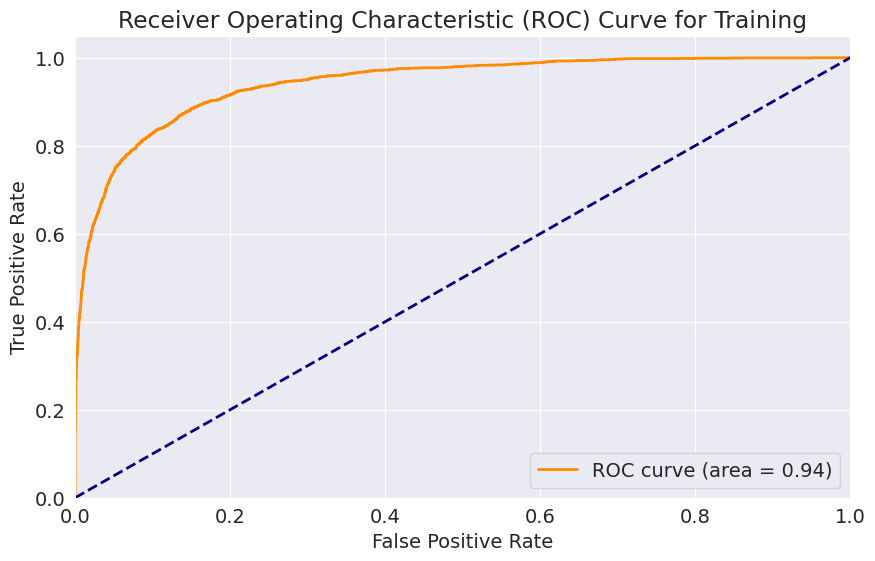

Точність на Validation вибірці:

AUROC for Validation: 0.94


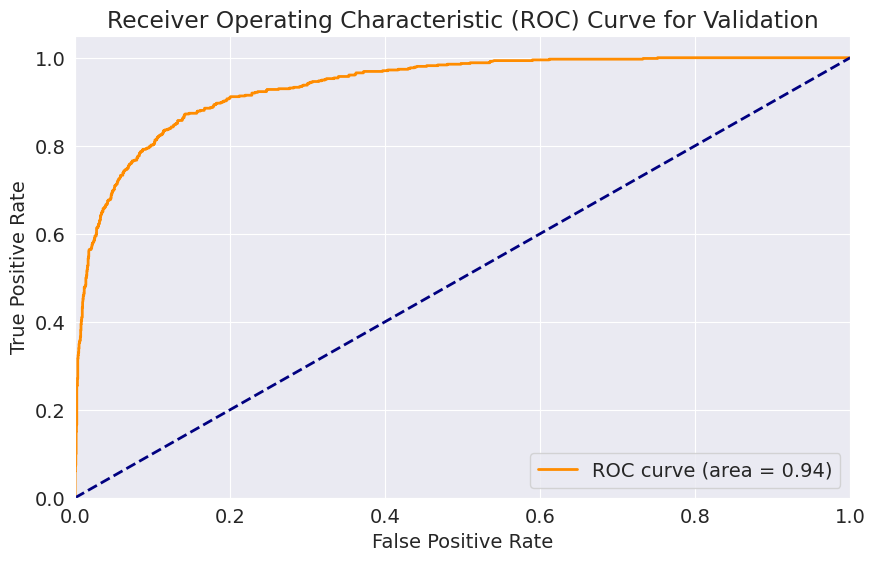

In [36]:
def objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params['n_estimators']),  # Кількість дерев у ансамблі (кількість ітерацій бустингу)
        learning_rate=params['learning_rate'],  # Коефіцієнт, на який зменшується внесок кожного доданого дерева
        max_depth=int(params['max_depth']),  # Максимальна глибина кожного дерева
        num_leaves=int(params['num_leaves']),  # Максимальна кількість листків, що дозволяємо кожному дереву мати.
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        min_split_gain=params['min_split_gain'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        cat_feature=cat_feature_indexes,  # Індекси категорійних ознак
        #device='cuda',
        random_state=42,
        early_stopping_round=10,
        metric='auc'
    )

    clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)], categorical_feature=cat_feature_indexes)

    pred = clf.predict_proba(val_inputs)[:, 1]
    auroc = roc_auc_score(val_targets, pred)

    return {'loss': -auroc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 400, 20),
    'learning_rate': hp.uniform('learning_rate', 0.03, 0.12),
    'max_depth': hp.quniform('max_depth', 3, 6, 1),
    'num_leaves': hp.quniform('num_leaves', 60, 90, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0.3, 1.5),
    'min_split_gain': hp.uniform('min_split_gain', 0.005, 0.03)
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['num_leaves'] = int(best['num_leaves'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf_lgb_min2 = lgb.LGBMClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    num_leaves=best['num_leaves'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    min_split_gain=best['min_split_gain'],
    cat_feature=cat_feature_indexes,
    #device='cuda',
    random_state=42,
    early_stopping_round=10,
    metric='auc'
)

final_clf_lgb_min2.fit(
    train_inputs,
    train_targets,
    eval_set=[(val_inputs, val_targets)],
    categorical_feature=cat_feature_indexes)

print("Точність на Train вибірці:\n")
compute_auroc_and_build_roc(final_clf_lgb_min2, train_inputs, train_targets, 'Training')
print("Точність на Validation вибірці:\n")
compute_auroc_and_build_roc(final_clf_lgb_min2, val_inputs, val_targets, 'Validation')

In [35]:
print(best)

{'colsample_bytree': np.float64(0.5880148727215033), 'learning_rate': np.float64(0.19113139541344154), 'max_depth': 3, 'min_child_weight': 5, 'min_split_gain': np.float64(0.04697677989451236), 'n_estimators': 480, 'num_leaves': 65, 'reg_alpha': np.float64(0.26532689274194143), 'reg_lambda': np.float64(0.3357649128936713), 'subsample': np.float64(0.5875783813891227)}


Покращень не отримала, тому залишаю першу модель LGB з кращими значенням auc val

6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

Оскільки результати на обох моделях за якістю однакові (0.94 auroc на всіх вибірках), то я б обрала модель LightGBM за критерієм меншої кількості дерев для тренування (150 estimators vs 475 XGBoost)

In [47]:
test_raw_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/test.csv')

In [48]:
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [49]:
test_raw_df = test_raw_df[input_cols]

In [50]:
test_raw_df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [51]:
test_raw_df[cat_features] = test_raw_df[cat_features].astype('category')

In [107]:
test_raw_df['Exited'] = final_clf_lgb.predict_proba(test_raw_df)[:, 1]

[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] bagging_freq is set=8, subsample_freq=0 will be ignored. Current value: bagging_freq=8


In [52]:
test_raw_df['Exited'] = final_clf_lgb_min2.predict_proba(test_raw_df)[:, 1]

In [54]:
test_raw_df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.132974
1,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.022581
2,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.070735
3,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.550839
4,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.040350


In [55]:
submission_log_reg_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/sample_submission.csv')

In [56]:
submission_log_reg_df['Exited'] = test_raw_df['Exited']

In [57]:
save_path = '/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/'
submission_log_reg_df.to_csv(save_path + 'submission_log_reg.csv', index=False)

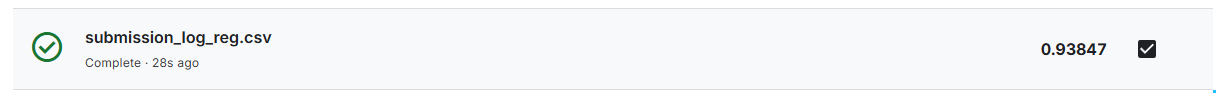

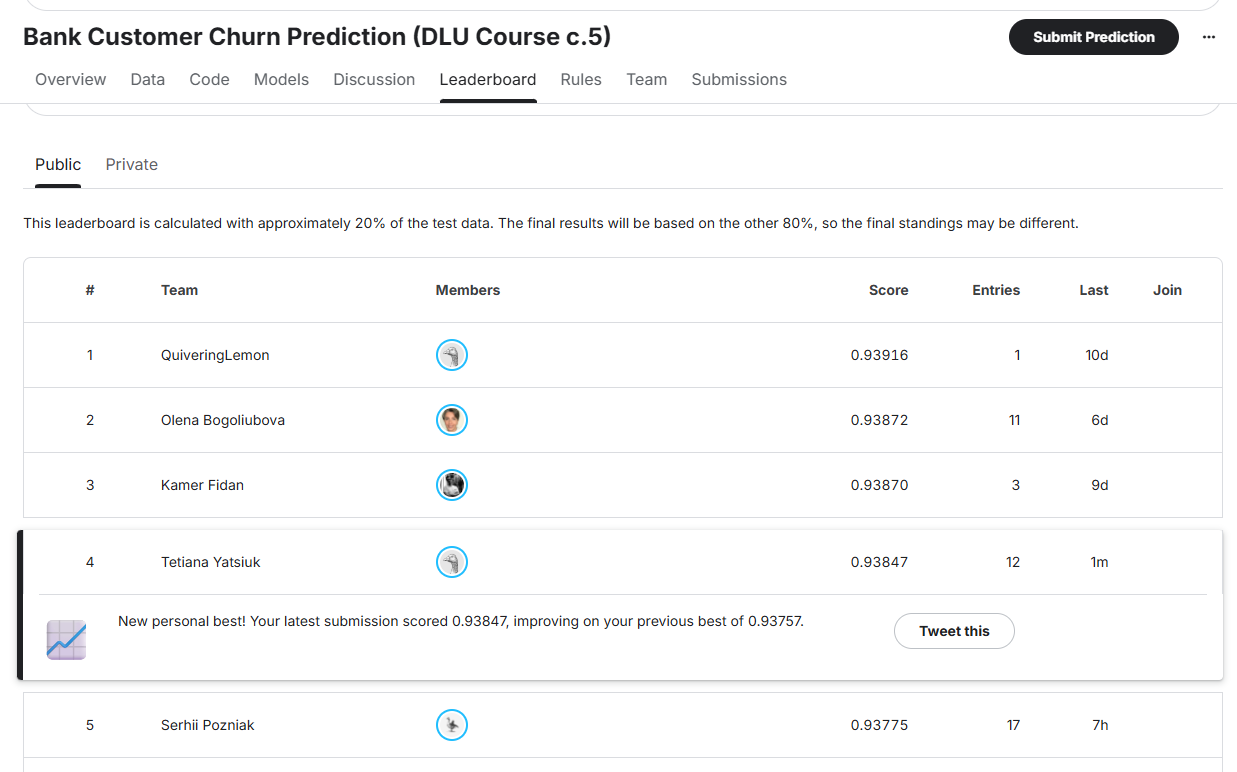

Спробую сабміт на моделі XGBoost

In [62]:
test_raw_df['Exited'] = final_clf_xgb.predict_proba(test_raw_df)[:, 1]

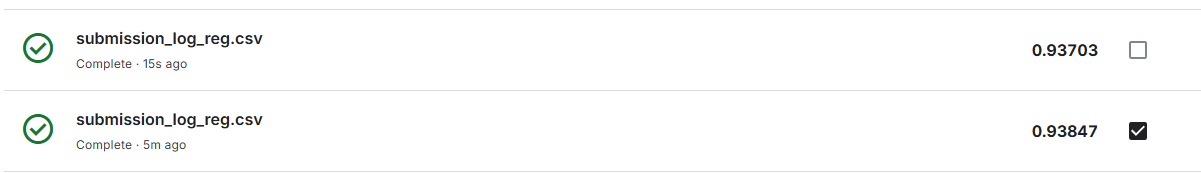

Результати гірші